In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, confusion_matrix, roc_curve, classification_report
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import RFE
import warnings
warnings.filterwarnings('ignore')

# Cấu hình hiển thị
plt.style.use('ggplot')

In [40]:
# Đọc dữ liệu
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

## Xử lí missing value và kiểu dữ liệu

In [41]:
# Xem thông tin tổng quát của các cột
print("Tên cột và kiểu dữ liệu:")
df.info()

Tên cột và kiểu dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling 

Khi nhìn vào kiểu dữ liêu của các thuộc tính có 2 đang không đúng kiểu dữ liệu là: TotalCharges (đang là object, lẽ ra là float64), SeniorCitizen - Là người cao tuổi (đang là int64 đáng lí phải là object)

In [42]:
# Kiểm tra tổng số giá trị thiếu theo cột
print("Số Missing Values theo từng cột:")
df.isna().sum()

Số Missing Values theo từng cột:


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [43]:
# Đếm tổng số dòng bị trùng lặp
print("Tổng số dòng dữ liệu bị trùng lặp:")
df.duplicated().sum()

Tổng số dòng dữ liệu bị trùng lặp:


np.int64(0)

Bộ dữ liệu không có missing value và không có dữ liệu trùng lặp

In [44]:
# Xử lí kiểu dữ liệu cho cột Senior Citizen
df['SeniorCitizen'] = df['SeniorCitizen'].astype('object')

# Đồng bộ Yes / No giống những cột khác
df['SeniorCitizen'] = df['SeniorCitizen'].replace({1: 'Yes', 0: 'No'})

Đổi kiểu dữ liệu của cột Senior Citizen về kiểu object, và chỉnh giá trị về Yes và No giống những cột khác

In [45]:
# Chuyển đổi kiểu dữ liệu của cột TotalCharges thành dạng số
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [46]:
# Kiểm tra lại tình trạng missing value
print("Số Missing Values theo từng cột:")
df.isna().sum()

Số Missing Values theo từng cột:


customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Lúc này đây xuất hiện 11 giá trị thiếu sau khi đổi kiểu dữ liệu của TotalCharges

In [47]:
# Lọc ra các dòng mà biến TotalCharges đang thiếu
rows_missing = df[df['TotalCharges'].isnull()]

# In ra dữ liệu của 11 dòng bị thiếu
print(rows_missing)

      customerID  gender SeniorCitizen Partner Dependents  tenure  \
488   4472-LVYGI  Female            No     Yes        Yes       0   
753   3115-CZMZD    Male            No      No        Yes       0   
936   5709-LVOEQ  Female            No     Yes        Yes       0   
1082  4367-NUYAO    Male            No     Yes        Yes       0   
1340  1371-DWPAZ  Female            No     Yes        Yes       0   
3331  7644-OMVMY    Male            No     Yes        Yes       0   
3826  3213-VVOLG    Male            No     Yes        Yes       0   
4380  2520-SGTTA  Female            No     Yes        Yes       0   
5218  2923-ARZLG    Male            No     Yes        Yes       0   
6670  4075-WKNIU  Female            No     Yes        Yes       0   
6754  2775-SEFEE    Male            No      No        Yes       0   

     PhoneService     MultipleLines InternetService       OnlineSecurity  ...  \
488            No  No phone service             DSL                  Yes  ...   
753      

Lúc này đây khi nhìn vào cột Tenure (Số tháng gắn bó với công ty) đều bằng 0, đây đều là những khách hàng mới, chưa hết tháng đầu tiên nên chưa phát sinh tổng hoá đơn (TotalCharges) là hợp tính hợp lí. Lúc này đây phải suy nghĩ để xử lí missing values:
- Khi đã đăng kí dịch vụ, thường phải thanh toán trước gói cước tháng đầu, khi TotalCharges = MonthlyCharges (đây là cách nghĩ của hình thức trả trước)
- Tuy nhiên khi xử lí theo cách đó sẽ tạo ra outlier trong mối quan hệ tuyến tính khi mà: những người khác Total / Montly = Tenure, còn 11 người này Total/Monthly = 1 (Mà Tenure = 0), sẽ tạo ra mâu thuẫn sẽ làm nhiễu mô hình sau này
- Nên nhóm quyết định, xử lí missing values chỗ này bằng cách điền 0 (phù hợp với cách nghĩ rằng đây là hình thức trả sau)

In [48]:
# Điền khuyết TotalCharges bằng giá trị 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [49]:
# Kiểm tra lại tình trạng missing value và kiểu dữ liệu
print("Tên cột và kiểu dữ liệu:")
df.info()

Tên cột và kiểu dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling 

Tình trạng missing values ở cột TotalCharges và kiểu dữ liệu các cột đều đã đúng

## Xử lí Outlier

In [50]:
# Kiểm tra outlier cho nhóm biến định lượng
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

def check_outliers_iqr(df, cols):
    print("=== KẾT QUẢ KIỂM TRA OUTLIER (PHƯƠNG PHÁP IQR) ===")

    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        # Xác định ngưỡng trên và dưới
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Lọc ra các dòng outlier
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        num_outliers = len(outliers)
        percentage = (num_outliers / len(df)) * 100

        print(f"\nbiến: {col}")
        print(f"- Khoảng chấp nhận: [{lower_bound:.2f}, {upper_bound:.2f}]")
        print(f"- Số lượng outlier: {num_outliers} dòng ({percentage:.2f}%)")

        # Nếu có outlier, in thử vài dòng để xem
        if num_outliers > 0:
            print(f"- Ví dụ dữ liệu outlier (Top 3):")
            print(outliers[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].head(3))

# Chạy hàm kiểm tra số liệu
check_outliers_iqr(df, numeric_cols)

=== KẾT QUẢ KIỂM TRA OUTLIER (PHƯƠNG PHÁP IQR) ===

biến: tenure
- Khoảng chấp nhận: [-60.00, 124.00]
- Số lượng outlier: 0 dòng (0.00%)

biến: MonthlyCharges
- Khoảng chấp nhận: [-46.02, 171.38]
- Số lượng outlier: 0 dòng (0.00%)

biến: TotalCharges
- Khoảng chấp nhận: [-4683.52, 8868.67]
- Số lượng outlier: 0 dòng (0.00%)


Sau khi kiểm tra outlier phát hiển các khoảng chấp nhận của các biến định lượng đều bao trùm đầy đủ các giá trị, kể cả những khách hàng VIP trả nhiều tiền nhất (Max của biến TotalCharges). Nên trong bài toán này không cần phải loại bỏ outliers

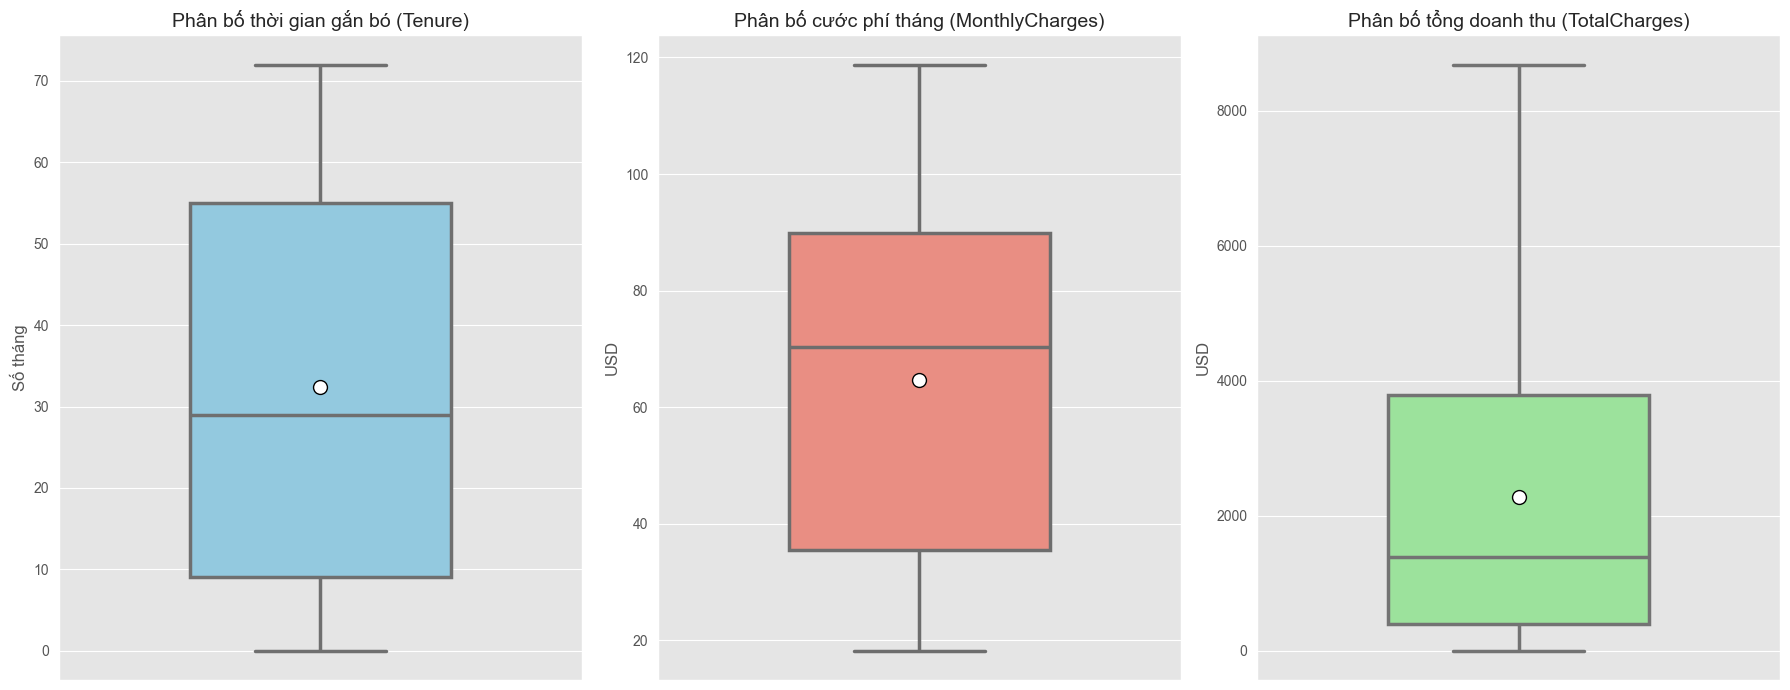

In [51]:
# Vẽ Boxplot để kiểm tra ngoại lai (Outliers)
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# Boxplot Tenure
sns.boxplot(y=df['tenure'], ax=axes[0], color='skyblue', width=0.5, linewidth=2.5, showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"10"})
axes[0].set_title('Phân bố thời gian gắn bó (Tenure)', fontsize=14)
axes[0].set_ylabel('Số tháng')

# Boxplot MonthlyCharges
sns.boxplot(y=df['MonthlyCharges'], ax=axes[1], color='salmon', width=0.5, linewidth=2.5, showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"10"})
axes[1].set_title('Phân bố cước phí tháng (MonthlyCharges)', fontsize=14)
axes[1].set_ylabel('USD')

# Boxplot TotalCharges
sns.boxplot(y=df['TotalCharges'], ax=axes[2], color='lightgreen', width=0.5, linewidth=2.5, showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"10"})
axes[2].set_title('Phân bố tổng doanh thu (TotalCharges)', fontsize=14)
axes[2].set_ylabel('USD')

plt.tight_layout()
plt.show()

Có thể thấy không có giá trị ngoại lai xuất hiện ngoài boxplot

## Feature Engineer - Tạo đặc trưng mới

Tạo thêm 5 biến mới, trích xuất từ các biến sẵn có

In [52]:
# Tạo biến Tổng số dịch vụ sử dụng (TotalServices)
# Khách dùng càng nhiều dịch vụ trong hệ sinh thái thì càng khó rời bỏ
services_cols = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
# Đếm số lượng dịch vụ khách hàng đang dùng (chỉ đếm nếu giá trị không phải 'No' hoặc 'No internet service')
df['TotalServices'] = df[services_cols].apply(lambda x: x.isin(['Yes', 'Fiber optic', 'DSL']).sum(), axis=1)

In [53]:
# Tạo biến giá cước trung bình trên mỗi dịch vụ AvgPricePerService
df['AvgPricePerService'] = df['MonthlyCharges'] / df['TotalServices'].replace(0, 1)

In [54]:
# Tạo biến Phân loại nhóm gia đình (FamilyCluster)
# 0: Độc thân, 1: Có Partner hoặc Con cái, 2: Có cả hai (Gia đình lớn)
df['FamilyCluster'] = df['Partner'].map({'Yes': 1, 'No': 0}) + df['Dependents'].map({'Yes': 1, 'No': 0})

In [55]:
# Tạo biến Gói an toàn & hỗ trợ (SupportPackage)
# Đếm số lượng dịch vụ kỹ thuật: Security, Backup, Protection, TechSupport
support_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
df['SupportPackage'] = df[support_cols].apply(lambda x: x.isin(['Yes']).sum(), axis=1)

In [56]:
# Tạo biến Nhóm nguy cơ cao (HighRiskProfile)
# Combo Hợp đồng tháng + Electronic check dễ gây Churn nhất
df['HighRiskProfile'] = ((df['Contract'] == 'Month-to-month') & (df['PaymentMethod'] == 'Electronic check')).astype(int)

In [57]:
# Xem thông tin tổng quát của các cột
print("Tên cột và kiểu dữ liệu sau khi Feature Engineering:")
df.info()

Tên cột và kiểu dữ liệu sau khi Feature Engineering:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 26 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customerID          7043 non-null   object 
 1   gender              7043 non-null   object 
 2   SeniorCitizen       7043 non-null   object 
 3   Partner             7043 non-null   object 
 4   Dependents          7043 non-null   object 
 5   tenure              7043 non-null   int64  
 6   PhoneService        7043 non-null   object 
 7   MultipleLines       7043 non-null   object 
 8   InternetService     7043 non-null   object 
 9   OnlineSecurity      7043 non-null   object 
 10  OnlineBackup        7043 non-null   object 
 11  DeviceProtection    7043 non-null   object 
 12  TechSupport         7043 non-null   object 
 13  StreamingTV         7043 non-null   object 
 14  StreamingMovies     7043 non-null   object 
 15  Co

## Chuẩn bị dữ liệu train

Tiền xử lí dữ liệu để chuẩn bị chạy thử mô hình

In [58]:
# Xóa cột customerID
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

Loại bỏ customerID vì đây là mã định danh khách hàng riêng biệt

In [59]:
# Mã hóa biến Target (Churn): Yes -> 1, No -> 0
if df['Churn'].dtype == 'object':
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [60]:
# One-Hot Encoding cho các biến phân loại
df = pd.get_dummies(df, drop_first=True)

In [61]:
# Tách X, y
X = df.drop('Churn', axis=1)
y = df['Churn']

In [62]:
# Chia train test (Có stratify)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [63]:
# Danh sách các biến cần Scale
cols_to_scale = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'TotalServices',
    'AvgPricePerService',
    'FamilyCluster',
    'SupportPackage'
]

# Kiểm tra xem các cột này có thực sự tồn tại trong X_train không
cols_to_scale = [col for col in cols_to_scale if col in X_train.columns]

In [64]:
# Khởi tạo Scaler
scaler = StandardScaler()

# Fit và Transform trên tập train
X_train_scaled = X_train.copy()
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# Chỉ Transform trên tập test
X_test_scaled = X_test.copy()
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [65]:
print("Dữ liệu sau khi Scale (5 dòng đầu của tập Train):")
print(X_train_scaled[cols_to_scale].head())

Dữ liệu sau khi Scale (5 dòng đầu của tập Train):
        tenure  MonthlyCharges  TotalCharges  TotalServices  \
3738  0.102371       -0.521976     -0.262257      -0.072199   
3151 -0.711743        0.337478     -0.503635      -0.503095   
4860 -0.793155       -0.809013     -0.749883      -0.072199   
3867 -0.263980        0.284384     -0.172722       0.789595   
3810 -1.281624       -0.676279     -0.989374      -0.933992   

      AvgPricePerService  FamilyCluster  SupportPackage  
3738           -0.922442      -0.960894       -0.215513  
3151            1.455427       1.495402       -0.215513  
4860           -1.326275       1.495402        1.337171  
3867           -0.931779       0.267254        0.560829  
3810            0.940326       1.495402       -0.991854  


In [66]:
print("\nKích thước tập train:", X_train_scaled.shape)
print("Kích thước tập test:", X_test_scaled.shape)


Kích thước tập train: (5634, 35)
Kích thước tập test: (1409, 35)


## Modeling

In [67]:
# HUẤN LUYỆN VÀ SO SÁNH ĐA MÔ HÌNH
# Định nghĩa danh sách mô hình
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Support Vector Machine": SVC(kernel='rbf', probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=10),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Biến lưu kết quả
results = []
roc_curves = {}
trained_models = {}

In [68]:
# Tiến hành huấn luyện mô hình
print("Đang bắt đầu huấn luyện các mô hình...")
# Vòng lặp training
for name, model in models.items():
    print(f"- Đang chạy: {name}...")

    # Train mô hình
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model # Lưu model lại

    # Dự đoán (Predict)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Tính các chỉ số đánh giá (Metrics)
    acc = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    precision = report['1']['precision']
    auc = roc_auc_score(y_test, y_prob)

    # Lưu kết quả vào list
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Recall (Churn)": recall,
        "Precision (Churn)": precision,
        "ROC-AUC": auc
    })

    # Lưu dữ liệu để vẽ biểu đồ ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_curves[name] = (fpr, tpr, auc)

print("Đã huấn luyện xong tất cả mô hình")

Đang bắt đầu huấn luyện các mô hình...
- Đang chạy: Logistic Regression...
- Đang chạy: K-Nearest Neighbors...
- Đang chạy: Support Vector Machine...
- Đang chạy: Decision Tree...
- Đang chạy: Random Forest...
Đã huấn luyện xong tất cả mô hình


### Đánh giá kết quả

In [69]:
# Tổng hợp và hiển thị bảng kết quả
results_df = pd.DataFrame(results).sort_values(by='ROC-AUC', ascending=False)

print("\n=== BẢNG XẾP HẠNG HIỆU NĂNG (Sắp xếp theo ROC-AUC) ===")
print(results_df)


=== BẢNG XẾP HẠNG HIỆU NĂNG (Sắp xếp theo ROC-AUC) ===
                    Model  Accuracy  Recall (Churn)  Precision (Churn)  \
0     Logistic Regression  0.801987        0.545455           0.651757   
4           Random Forest  0.789922        0.502674           0.630872   
2  Support Vector Machine  0.794890        0.500000           0.647059   
1     K-Nearest Neighbors  0.758694        0.521390           0.547753   
3           Decision Tree  0.775018        0.542781           0.581662   

    ROC-AUC  
0  0.842225  
4  0.822047  
2  0.795285  
1  0.766229  
3  0.761949  


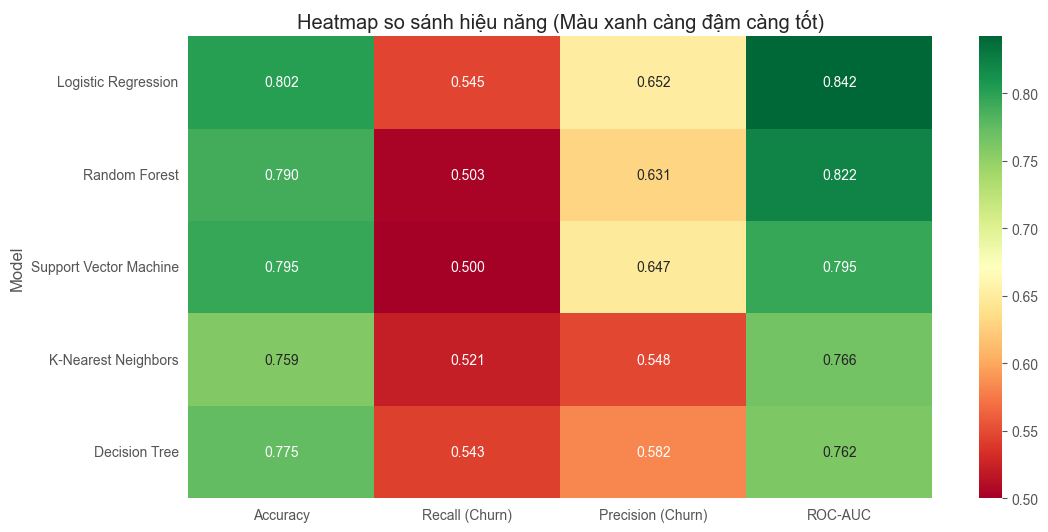

In [70]:
# Vẽ Heatmap so sánh các chỉ số
plt.figure(figsize=(12, 6))
sns.heatmap(results_df.set_index('Model'), annot=True, cmap='RdYlGn', fmt='.3f')
plt.title('Heatmap so sánh hiệu năng (Màu xanh càng đậm càng tốt)')
plt.show()

- Mô hình đặt được kết quả tốt nhất: Logistic Regression đang dẫn đầu về chỉ số ROC-AUC (0.8422) và Accuracy (0.802). Chỉ số Recall và Precision tốt nhất (0.5455) nhưng chưa được tối ưu
- Random Forest đứng vị trí thứ hai: chỉ số ROC - AUC (0.822) và accuracy (0.79). Chỉ số Recall (0.503) cho thấy cứ 2 người định rời bỏ sẽ chỉ dự đoán được 1 người, đây là chỗ cần phải tối ưu

### Phân tích độ quan trọng của biến (FEATURE IMPORTANCE)

Trong phần này, nhóm tiến hành sử dụng nhiều kĩ thuật tìm Feature Importance, để tìm kiếm bộ biến rút gọn đóng góp nhiều nhất vào quá trình dự đoán của mô hình sau đó tiến hành train lại mô hình với bộ biến này

#### Correlation Analysis (Tương quan tuyến tính) - Kiểm tra quan hệ đơn lẻ giữa từng biến và Target (Churn)

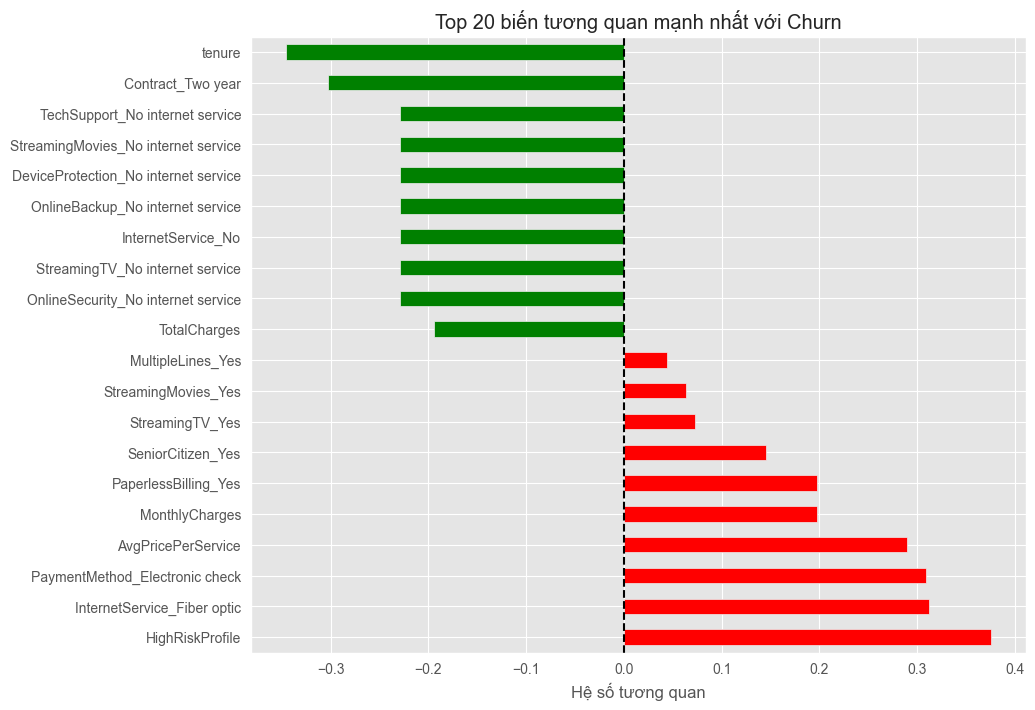

In [71]:
# Correlation Analysis: Tương quan tuyến tính
# Tạo dataframe tạm để tính correlation
temp_train = X_train_scaled.copy()
temp_train['Churn'] = y_train.values

# Tính correlation
corr_matrix = temp_train.corr()
corr_with_churn = corr_matrix['Churn'].drop('Churn').sort_values(ascending=False)

# Vẽ biểu đồ Top 20
plt.figure(figsize=(10, 8))
top_corr = pd.concat([corr_with_churn.head(10), corr_with_churn.tail(10)])
colors = ['red' if x > 0 else 'green' for x in top_corr.values]
top_corr.plot(kind='barh', color=colors)
plt.title('Top 20 biến tương quan mạnh nhất với Churn')
plt.xlabel('Hệ số tương quan')
plt.axvline(x=0, color='black', linestyle='--')
plt.show()

#### Logistic Regression Coefficients - Trọng số của phương trình hồi quy

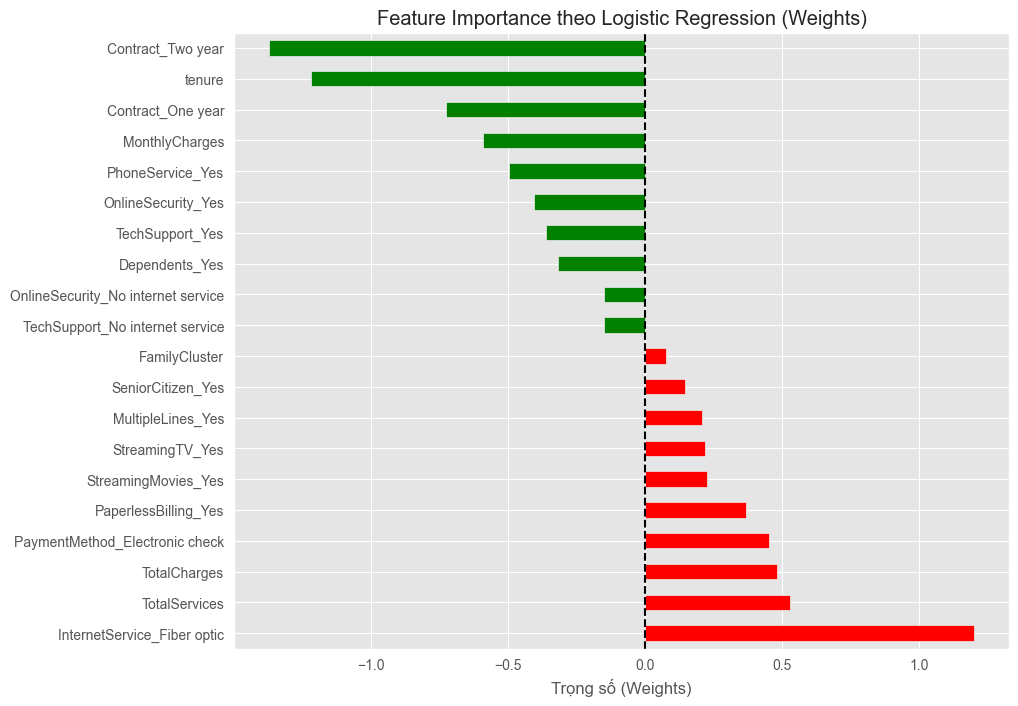

In [72]:
# Sử dụng model Logistic Regression đã train ở trên để xem trọng số
# Lấy model từ dictionary đã lưu
log_model = trained_models["Logistic Regression"]
feature_names = X_train_scaled.columns

# Lấy hệ số
weights = pd.Series(log_model.coef_[0], index=feature_names).sort_values(ascending=False)

# Vẽ biểu đồ
plt.figure(figsize=(10, 8))
top_weights = pd.concat([weights.head(10), weights.tail(10)])
colors = ['red' if x > 0 else 'green' for x in top_weights.values]
top_weights.plot(kind='barh', color=colors)
plt.title('Feature Importance theo Logistic Regression (Weights)')
plt.xlabel('Trọng số (Weights)')
plt.axvline(x=0, color='black', linestyle='--')
plt.show()

#### Random Forest Feature Importance (MDI) - Mức độ đóng góp của biến trong cây quyết định

Top 10 biến quan trọng nhất theo Random Forest:
TotalCharges                   0.145625
tenure                         0.142534
AvgPricePerService             0.128333
MonthlyCharges                 0.119935
HighRiskProfile                0.043087
TotalServices                  0.030052
SupportPackage                 0.028392
InternetService_Fiber optic    0.028365
Contract_Two year              0.027357
gender_Male                    0.023934
dtype: float64


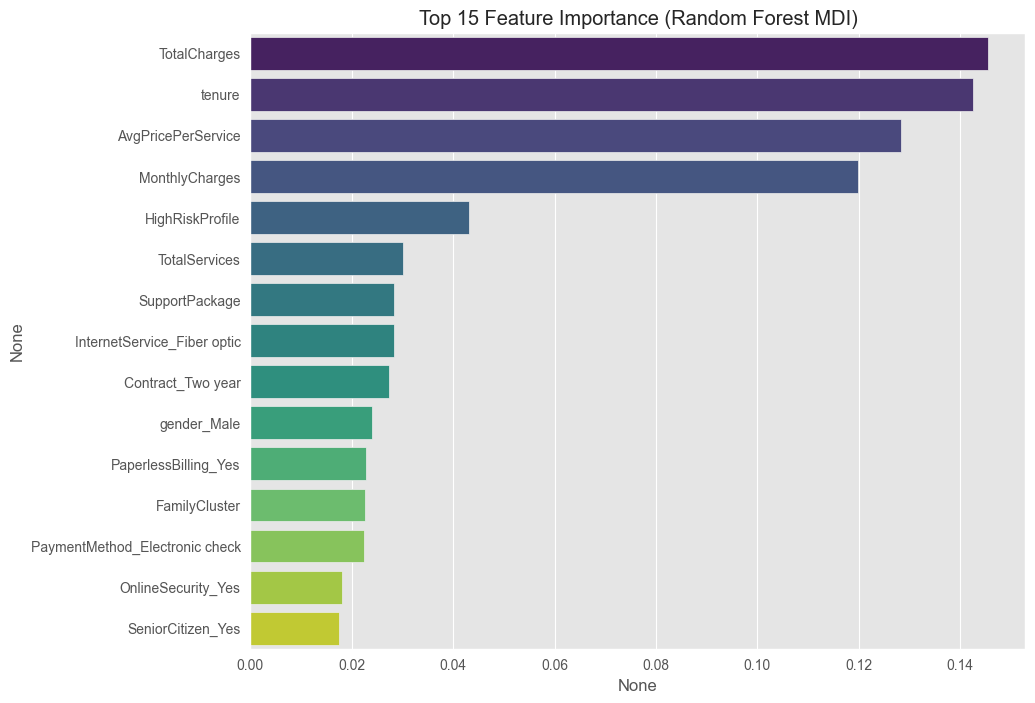

In [73]:
# Sử dụng model Random Forest đã train ở trên. Đây là kỹ thuật quan trọng để bắt các mối quan hệ phi tuyến tính

# Lấy model Random Forest
rf_model = trained_models["Random Forest"]

# Lấy độ quan trọng
rf_importances = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)

# In top 10 biến
print("Top 10 biến quan trọng nhất theo Random Forest:")
print(rf_importances.head(10))

# Vẽ biểu đồ
plt.figure(figsize=(10, 8))
sns.barplot(x=rf_importances.head(15), y=rf_importances.head(15).index, palette='viridis')
plt.title('Top 15 Feature Importance (Random Forest MDI)')
plt.show()

#### Permutation Importance -  Đánh giá độ quan trọng bằng cách xáo trộn dữ liệu trên tập Test

In [ ]:
# Đánh giá độ quan trọng bằng cách xáo trộn dữ liệu trên tập Test. Đây là thước đo khách quan nhất về độ mạnh của biến.
print("Đang tính toán Permutation Importance...")
# Dùng model Random Forest để tính
perm_result = permutation_importance(rf_model, X_test_scaled, y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Sắp xếp index giảm dần
perm_sorted_idx = perm_result.importances_mean.argsort()[::-1]

# Vẽ Boxplot
plt.figure(figsize=(10, 8))
plt.boxplot(perm_result.importances[perm_sorted_idx[:15]].T, vert=False, labels=feature_names[perm_sorted_idx[:15]])
plt.title('Permutation Importance (Đánh giá trên tập Test)')
plt.xlabel('Mức độ giảm độ chính xác (Accuracy Drop)')
plt.tight_layout()
plt.show()

Đang tính toán Permutation Importance...


#### Recursive Feature Elimination (RFE) - Loại bỏ đệ quy để chọn ra tập hợp các biến tinh túy nhất

In [37]:
# Loại bỏ đệ quy để chọn ra tập hợp các biến tinh túy nhất
print("Đang chạy RFE để chọn ra 10 biến tốt nhất...")
# Dùng Random Forest làm lõi cho RFE
rfe_selector = RFE(estimator=RandomForestClassifier(n_estimators=50, random_state=42), n_features_to_select=10, step=1)
rfe_selector.fit(X_train_scaled, y_train)

# Tạo bảng ranking
rfe_ranking = pd.DataFrame({
    'Feature': feature_names,
    'Ranking': rfe_selector.ranking_,
    'Selected': rfe_selector.support_
}).sort_values(by='Ranking')

print("\n=== TOP 10 BIẾN ĐƯỢC RFE LỰA CHỌN ===")
print(rfe_ranking[rfe_ranking['Ranking'] == 1]['Feature'].tolist())

Đang chạy RFE để chọn ra 10 biến tốt nhất...

=== TOP 10 BIẾN ĐƯỢC RFE LỰA CHỌN ===
['tenure', 'MonthlyCharges', 'TotalCharges', 'TotalServices', 'AvgPricePerService', 'FamilyCluster', 'SupportPackage', 'HighRiskProfile', 'gender_Male', 'InternetService_Fiber optic']


#### TỔNG HỢP KẾT QUẢ (FINAL SCORE)


=== BẢNG XẾP HẠNG ĐỘ QUAN TRỌNG TỔNG HỢP (TOP 15) ===
                                LogReg_Score  RF_Score  Perm_Score  \
tenure                                 0.886     0.978       1.000   
TotalCharges                           0.343     1.000       0.438   
MonthlyCharges                         0.421     0.820       0.235   
InternetService_Fiber optic            0.874     0.180       0.399   
Contract_Two year                      1.000     0.173       0.198   
AvgPricePerService                     0.036     0.879       0.000   
Contract_One year                      0.523     0.081       0.146   
PaperlessBilling_Yes                   0.258     0.141       0.294   
TotalServices                          0.377     0.192       0.111   
PaymentMethod_Electronic check         0.320     0.138       0.158   
OnlineSecurity_Yes                     0.284     0.107       0.154   
HighRiskProfile                        0.051     0.283       0.142   
PhoneService_Yes                   

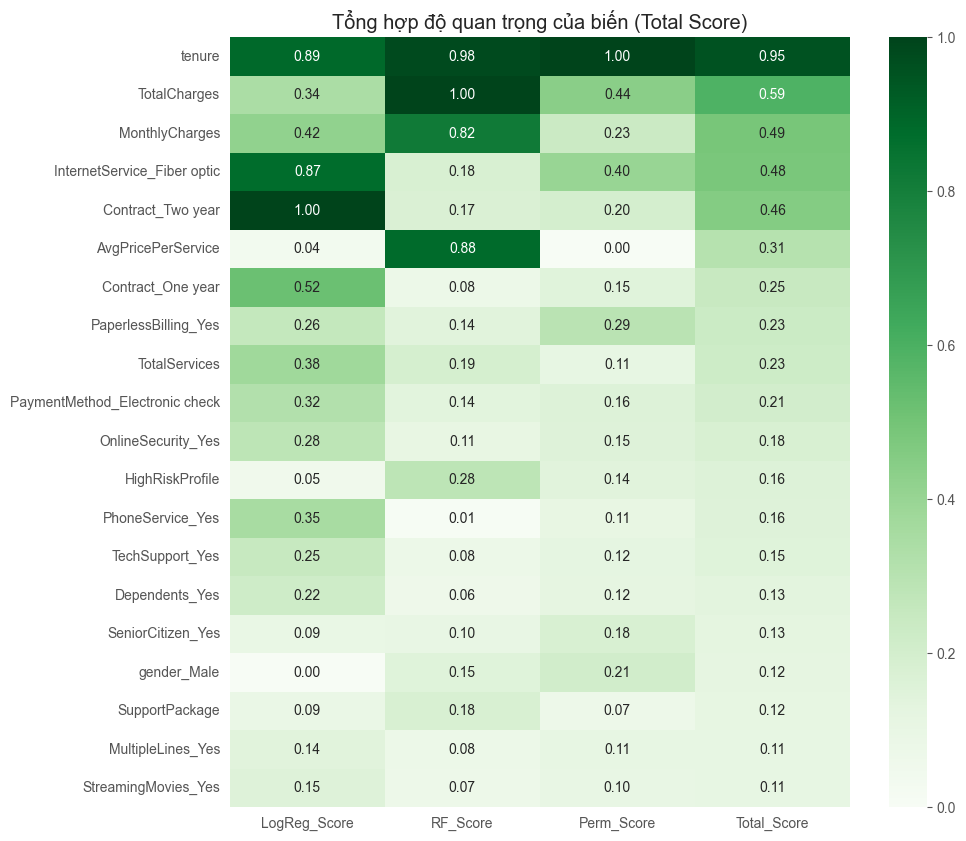

In [38]:
# Kết hợp các kỹ thuật lại để ra bảng xếp hạng cuối cùng
# Tổng hợp dữ liệu
summary_df = pd.DataFrame({
    'Feature': feature_names,
    'LogReg_Weight_Abs': abs(weights[feature_names]),
    'RF_Importance': rf_importances[feature_names],
    'Permutation_Mean': perm_result.importances_mean
})

# Hàm chuẩn hóa Min-Max (đưa về thang 0-1)
def min_max_scale(series):
    return (series - series.min()) / (series.max() - series.min())

# Tính điểm
summary_df['LogReg_Score'] = min_max_scale(summary_df['LogReg_Weight_Abs'])
summary_df['RF_Score'] = min_max_scale(summary_df['RF_Importance'])
summary_df['Perm_Score'] = min_max_scale(summary_df['Permutation_Mean'])

# Tính điểm tổng
summary_df['Total_Score'] = (summary_df['LogReg_Score'] + summary_df['RF_Score'] + summary_df['Perm_Score']) / 3
summary_df = summary_df.sort_values(by='Total_Score', ascending=False)

print("\n=== BẢNG XẾP HẠNG ĐỘ QUAN TRỌNG TỔNG HỢP (TOP 15) ===")
print(summary_df[['LogReg_Score', 'RF_Score', 'Perm_Score', 'Total_Score']].head(15).round(3))

# Vẽ Heatmap tổng hợp
plt.figure(figsize=(10, 10))
sns.heatmap(summary_df[['LogReg_Score', 'RF_Score', 'Perm_Score', 'Total_Score']].head(20),
            annot=True, cmap='Greens', fmt='.2f')
plt.title('Tổng hợp độ quan trọng của biến (Total Score)')
plt.show()

Sau khi quan sát kết quả tổng hợp từ 5 phương pháp (Total Score), nhóm quyết định chọn bộ 9 biến gọn nhẹ nhưng hiệu quả cao nhất gồm:
- tenure: 0.955
- TotalCharges: 0.594
- MonthlyCharges: 0.492
- InternetService: 0.484
- Contract: 0.457
- AvgPricePerService: 0.305
- PaperlessBilling: 0.231
- TotalServices: 0.226
- PaymentMethod: 0.205
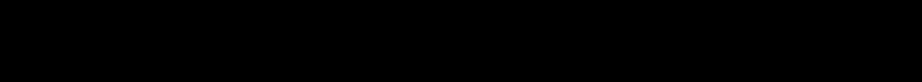